# PA-28 / PA-29 / PA-30 / PA-31 / PA-09 — Pipeline VAD + Diarisation + SER
**Sprint 2-3 | Équipe P07 | Projet Stellantis**

Ce notebook intègre l'ensemble du pipeline audio :
- **PA-28** : VAD (Silero) + Diarisation (pyannote) — validation du pipeline de base
- **PA-29** : Visualisation timeline des locuteurs
- **PA-30** : Exécution sur AMI Corpus, multi-fichiers avec échantillon aléatoire
- **PA-27** : Benchmark chunks glissants — tableau comparatif latence / justesse pour le choix de X
- **PA-31** : Évaluation DER avec comparaison visuelle référence vs prédiction
- **PA-09** : Reconnaissance d'émotions (SER) via wav2vec2 HuggingFace — segment par segment

**Modèle SER :** `ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition`
Basé sur : *George & Ilyas — A review on speech emotion recognition (Neurocomputing, 2024)*

**Prérequis :** token HuggingFace configuré dans les secrets Colab (`HF_TOKEN`).


## 1. Installation des dépendances
Redémarrer le runtime après cette cellule.

In [3]:
import sys
# Upgrade numpy/scipy d'abord pour eviter les conflits de version (depuis P07-Projet_audio)
!{sys.executable} -m pip install -q --upgrade numpy scipy
!{sys.executable} -m pip install -q pyannote.audio silero-vad librosa soundfile
print('Installation OK - redémarre le runtime !')

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

## 2. Chargement des modèles
Patch de compatibilité torchaudio + chargement de Silero VAD et du pipeline pyannote.

In [4]:
import torchaudio, torch
import librosa, soundfile as sf
import numpy as np
import json, os, datetime
from IPython.display import Audio, display

# Patch compatibilite torchaudio / pyannote
if not hasattr(torchaudio, 'AudioMetaData'):
    try:
        from torchaudio._backend.utils import AudioMetaData
    except Exception:
        import collections
        AudioMetaData = collections.namedtuple('AudioMetaData',
            ['sample_rate', 'num_frames', 'num_channels', 'bits_per_sample', 'encoding'])
    torchaudio.AudioMetaData = AudioMetaData

from pyannote.audio import Pipeline
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
pipeline = Pipeline.from_pretrained(
    'pyannote/speaker-diarization-3.1',
    token=HF_TOKEN
)
print('pyannote charge')

# Silero VAD
vad_model, utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad',
    model='silero_vad',
    force_reload=False,
    trust_repo=True
)
(get_speech_timestamps, save_audio, read_audio, VADIterator, collect_chunks) = utils
print('Silero VAD charge')

SAMPLE_RATE = 16000
print('Imports OK')

pyannote charge
Silero VAD charge
Imports OK


Using cache found in /root/.cache/torch/hub/snakers4_silero-vad_master


## 3. Upload des fichiers audio
Uploader un ou plusieurs fichiers audio (wav, flac, mp3, etc.).
Le script en sélectionne un échantillon aléatoire de 3 fichiers si plusieurs sont uploadés.
Chaque fichier est converti en wav 16kHz mono (format requis par Silero VAD et pyannote).


In [5]:
from google.colab import files
import os, random, librosa, soundfile as sf
import torchaudio
from IPython.display import Audio, display

uploaded = files.upload()
all_files = list(uploaded.keys())
print(f'{len(all_files)} fichier(s) uploade(s) : {all_files}')

# Echantillon aleatoire : max 3 fichiers
N_SAMPLE = min(3, len(all_files))
sample_files = random.sample(all_files, N_SAMPLE)
print(f'\nEchantillon selectionne ({N_SAMPLE} fichier(s)) :')
for f in sample_files:
    print(f'  - {f}')

# Conversion en wav 16kHz mono
converted_files = []
os.makedirs('ami_converted', exist_ok=True)

for fname in sample_files:
    audio, sr = librosa.load(fname, sr=16000, mono=True)
    out_path = f'ami_converted/{os.path.splitext(fname)[0]}.wav'
    sf.write(out_path, audio, 16000)
    converted_files.append(out_path)
    print(f'Converti : {fname} -> {out_path} ({len(audio)/16000:.1f}s)')

# Ecoute du premier fichier (PA-29 / depuis P07-Projet_audio)
if converted_files:
    AUDIO_PATH = converted_files[0]
    waveform, sr_loaded = torchaudio.load(AUDIO_PATH)
    print(f'\nApercu audio : {AUDIO_PATH}')
    display(Audio(waveform.numpy(), rate=sr_loaded))

Saving Audio_test.m4a to Audio_test (1).m4a
1 fichier(s) uploade(s) : ['Audio_test (1).m4a']

Echantillon selectionne (1 fichier(s)) :
  - Audio_test (1).m4a


/tmp/ipykernel_2379/2227851031.py:22: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(fname, sr=16000, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Converti : Audio_test (1).m4a -> ami_converted/Audio_test (1).wav (53.9s)

Apercu audio : ami_converted/Audio_test (1).wav


## 4. Exécution du pipeline sur l'échantillon
Pour chaque fichier : VAD → Diarisation → export JSON.

In [6]:
def extract_annotation(diar_output):
    """
    pyannote peut retourner :
      - une Annotation directement (versions recentes)
      - un DiarizeOutput avec attribut .speaker_diarization (anciennes)
    Cette fonction normalise les deux cas.
    """
    if hasattr(diar_output, 'itertracks'):
        return diar_output                   # c'est deja une Annotation
    if hasattr(diar_output, 'speaker_diarization'):
        return diar_output.speaker_diarization
    # Fallback : tente tous les attributs Annotation connus
    for attr in ('annotation', 'diarization', 'segmentation'):
        if hasattr(diar_output, attr):
            return getattr(diar_output, attr)
    raise TypeError(f'Type de retour pyannote inconnu : {type(diar_output)}')

all_results = {}

for audio_path in converted_files:
    print(f'\n{"="*55}')
    print(f'Traitement : {audio_path}')
    print('='*55)

    waveform, sr = torchaudio.load(audio_path)
    audio_1d = waveform.squeeze(0)
    duration = audio_1d.shape[0] / SAMPLE_RATE

    # VAD
    speech_timestamps = get_speech_timestamps(
        audio_1d, vad_model,
        sampling_rate=SAMPLE_RATE,
        threshold=0.5,
        min_speech_duration_ms=300,
        min_silence_duration_ms=200
    )
    print(f'  VAD : {len(speech_timestamps)} segment(s) de parole detecte(s)')

    # Diarisation — normalisation du type de retour pyannote
    diar_output = pipeline(audio_path)
    annotation  = extract_annotation(diar_output)

    segments = []
    for segment, track, speaker in annotation.itertracks(yield_label=True):
        seg = {'start': round(segment.start, 3), 'end': round(segment.end, 3), 'speaker': speaker}
        segments.append(seg)
        print(f'  [{seg["start"]:6.2f}s -> {seg["end"]:6.2f}s]  {speaker}')

    speakers_detected = list(set(s['speaker'] for s in segments))
    result = {
        'metadata': {
            'audio_file':            os.path.basename(audio_path),
            'duration_s':            round(duration, 3),
            'processed_at':          datetime.datetime.now().isoformat(),
            'vad_model':             'silero-vad',
            'diarization_model':     'pyannote/speaker-diarization-3.1',
            'num_speakers_detected': len(speakers_detected)
        },
        'speakers':  speakers_detected,
        'segments':  segments
    }
    all_results[audio_path] = result

    json_path = audio_path.replace('.wav', '_output.json')
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(result, f, ensure_ascii=False, indent=2)
    print(f'  JSON sauvegarde -> {json_path}')
    print(f'  Locuteurs detectes : {len(speakers_detected)} | Segments : {len(segments)}')

print(f'\nPipeline termine sur {len(converted_files)} fichier(s)')



Traitement : ami_converted/Audio_test (1).wav
  VAD : 10 segment(s) de parole detecte(s)


/usr/local/lib/python3.12/dist-packages/pyannote/audio/models/blocks/pooling.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  std = sequences.std(dim=-1, correction=1)


  [  1.57s ->   2.09s]  SPEAKER_00
  [  2.92s ->   3.37s]  SPEAKER_03
  [  4.25s ->   4.27s]  SPEAKER_03
  [  4.27s ->   4.66s]  SPEAKER_00
  [  4.66s ->   4.67s]  SPEAKER_03
  [  4.67s ->   4.74s]  SPEAKER_00
  [  4.74s ->   5.94s]  SPEAKER_03
  [  5.94s ->   6.78s]  SPEAKER_00
  [  7.19s ->  11.71s]  SPEAKER_00
  [ 12.06s ->  13.85s]  SPEAKER_02
  [ 14.15s ->  16.03s]  SPEAKER_03
  [ 16.03s ->  16.59s]  SPEAKER_00
  [ 16.59s ->  16.60s]  SPEAKER_03
  [ 16.60s ->  16.64s]  SPEAKER_00
  [ 16.77s ->  20.05s]  SPEAKER_00
  [ 20.26s ->  23.35s]  SPEAKER_00
  [ 23.55s ->  25.41s]  SPEAKER_02
  [ 25.80s ->  25.93s]  SPEAKER_02
  [ 25.93s ->  25.95s]  SPEAKER_00
  [ 25.95s ->  26.04s]  SPEAKER_02
  [ 26.04s ->  27.34s]  SPEAKER_00
  [ 27.34s ->  27.35s]  SPEAKER_02
  [ 27.69s ->  28.90s]  SPEAKER_00
  [ 29.21s ->  32.04s]  SPEAKER_00
  [ 32.41s ->  34.54s]  SPEAKER_01
  [ 34.95s ->  37.29s]  SPEAKER_00
  [ 37.85s ->  39.05s]  SPEAKER_00
  [ 40.01s ->  43.62s]  SPEAKER_00
  [ 43.94s ->  44.88

## 4bis. Validation PA-28
Vérification des critères d'acceptation de la user story PA-28.

In [7]:
# Validation sur le premier fichier traite
first_path = converted_files[0]
first_result = all_results[first_path]

print('=' * 50)
print('VALIDATION PA-28')
print('=' * 50)

wf_check, _ = torchaudio.load(first_path)
audio_check  = wf_check.squeeze(0)
vad_check    = get_speech_timestamps(audio_check, vad_model, sampling_rate=SAMPLE_RATE,
                                     threshold=0.5, min_speech_duration_ms=300, min_silence_duration_ms=200)

c1 = len(vad_check) > 0
c2 = len(first_result['segments']) > 0

print(f'Critere 1 - Pipeline sans plantage     : {"PASS" if c1 and c2 else "FAIL"}')
print(f'Critere 2 - Sortie brute voix+segments : {"PASS" if c2 else "FAIL"}')
print(f'\nLocuteurs detectes : {first_result["metadata"]["num_speakers_detected"]}')
print(f'Segments produits  : {len(first_result["segments"])}')
print('=' * 50)

VALIDATION PA-28
Critere 1 - Pipeline sans plantage     : PASS
Critere 2 - Sortie brute voix+segments : PASS

Locuteurs detectes : 4
Segments produits  : 33


## 5. Visualisation des résultats — Timeline des locuteurs (PA-29)
Timeline des locuteurs pour chaque fichier de l'échantillon.

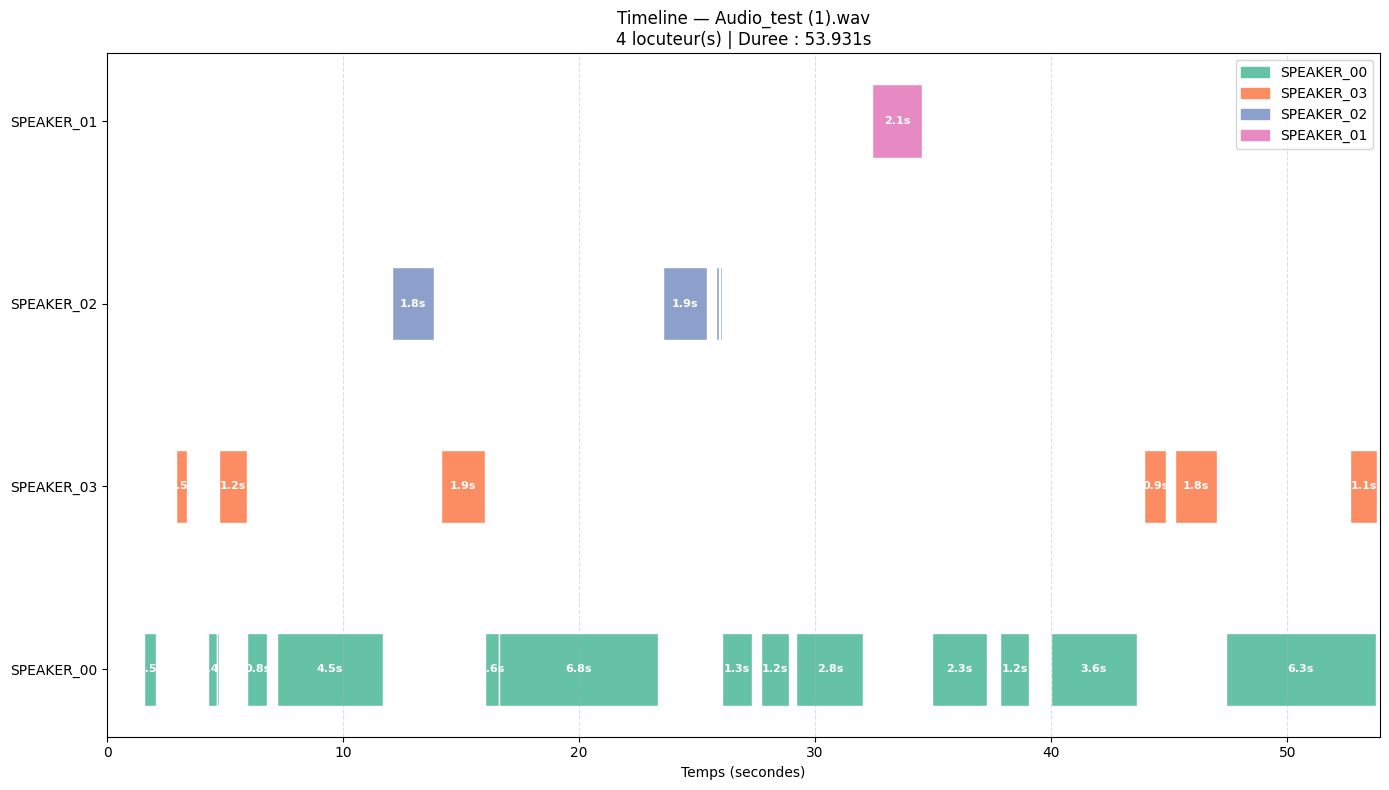

Timeline sauvegardee -> ami_converted/Audio_test (1)_timeline.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def merge_segments(segs, gap=0.3):
    merged = []
    for seg in sorted(segs, key=lambda x: x['start']):
        if merged and seg['speaker'] == merged[-1]['speaker'] and seg['start'] - merged[-1]['end'] < gap:
            merged[-1]['end'] = seg['end']
        else:
            merged.append(dict(seg))
    return merged

colors = plt.cm.Set2.colors

for audio_path, result in all_results.items():
    segments_merged = merge_segments(result['segments'])
    speakers = list(dict.fromkeys(s['speaker'] for s in segments_merged))
    speaker_colors = {spk: colors[i % len(colors)] for i, spk in enumerate(speakers)}

    fig, ax = plt.subplots(figsize=(14, 2 + len(speakers) * 1.5))
    for seg in segments_merged:
        ax.barh(y=seg['speaker'], width=seg['end']-seg['start'],
                left=seg['start'], color=speaker_colors[seg['speaker']],
                edgecolor='white', height=0.4)
        dur = seg['end'] - seg['start']
        if dur > 0.3:
            ax.text(seg['start'] + dur/2, seg['speaker'],
                    f'{dur:.1f}s', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')

    patches = [mpatches.Patch(color=speaker_colors[spk], label=spk) for spk in speakers]
    ax.legend(handles=patches, loc='upper right')
    ax.set_xlabel('Temps (secondes)')
    ax.set_title(f"Timeline — {result['metadata']['audio_file']}\n"
                 f"{result['metadata']['num_speakers_detected']} locuteur(s) | "
                 f"Duree : {result['metadata']['duration_s']}s")
    ax.set_xlim(0, result['metadata']['duration_s'])
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()

    img_path = audio_path.replace('.wav', '_timeline.png')
    plt.savefig(img_path, dpi=150)
    plt.show()
    print(f'Timeline sauvegardee -> {img_path}')

## 5bis. Mesure de la latence du pipeline VAD
**Critère d'acceptation :** Temps de traitement mesuré et affiché pour évaluer la compatibilité embarquée (Raspberry Pi).

Cette cellule rejoue uniquement la phase VAD sur le fichier converti et mesure précisément le temps d'exécution.


In [9]:
import time

if not converted_files:
    raise RuntimeError('Aucun fichier converti. Executer la cellule Upload d abord.')

audio_path_latency = converted_files[0]
waveform_lat, _ = torchaudio.load(audio_path_latency)
audio_1d_lat    = waveform_lat.squeeze(0)
audio_duration_s = audio_1d_lat.shape[0] / SAMPLE_RATE

print('=' * 55)
print('  MESURE DE LATENCE — PIPELINE VAD')
print('=' * 55)
print(f'  Fichier        : {audio_path_latency}')
print(f'  Duree audio    : {audio_duration_s:.2f} s')
print()

N_RUNS = 5
latencies = []

for i in range(N_RUNS):
    t_start = time.perf_counter()
    _ = get_speech_timestamps(
        audio_1d_lat, vad_model,
        sampling_rate=SAMPLE_RATE,
        threshold=0.5,
        min_speech_duration_ms=300,
        min_silence_duration_ms=200
    )
    t_end = time.perf_counter()
    elapsed = t_end - t_start
    latencies.append(elapsed)
    print(f'  Run {i+1}/{N_RUNS} : {elapsed*1000:.1f} ms')

lat_mean = sum(latencies) / N_RUNS
lat_min  = min(latencies)
lat_max  = max(latencies)
rtf      = lat_mean / audio_duration_s

print()
print('=' * 55)
print(f'  Latence moyenne : {lat_mean*1000:.1f} ms')
print(f'  Latence min     : {lat_min*1000:.1f} ms')
print(f'  Latence max     : {lat_max*1000:.1f} ms')
print(f'  Real-Time Factor: {rtf:.4f}  (< 1.0 = plus rapide que temps reel)')
print()

if lat_mean < 1.0:
    compat = 'Compatible embarque (< 1 s de latence)'
elif lat_mean < 3.0:
    compat = 'Latence acceptable mais a optimiser (1-3 s)'
else:
    compat = 'Latence trop elevee pour un usage embarque'
print(f'  Interpretation  : {compat}')
print('=' * 55)

  MESURE DE LATENCE — PIPELINE VAD
  Fichier        : ami_converted/Audio_test (1).wav
  Duree audio    : 53.93 s

  Run 1/5 : 1187.7 ms
  Run 2/5 : 842.2 ms
  Run 3/5 : 786.2 ms
  Run 4/5 : 779.7 ms
  Run 5/5 : 777.1 ms

  Latence moyenne : 874.6 ms
  Latence min     : 777.1 ms
  Latence max     : 1187.7 ms
  Real-Time Factor: 0.0162  (< 1.0 = plus rapide que temps reel)

  Interpretation  : Compatible embarque (< 1 s de latence)


## 5ter. PA-27 — Tableau comparatif latence / justesse pour le choix de X

**Architecture retenue : chunks glissants**
L'audio est découpé en fenêtres de **X secondes** traitées successivement, ce qui permet d'obtenir un résultat partiel toutes les X secondes sans attendre la fin de la conversation.

Cette cellule mesure le pipeline VAD sur **10 tailles de chunk** (de 5 à 120 secondes) et produit un tableau comparatif pour choisir la valeur de X à proposer au client.

**Critère d'acceptation (PA-27) :** tableau latence/justesse produit, valeur X recommandée justifiée.


  PA-27 — BENCHMARK CHUNKS GLISSANTS (10 tailles testees)
  Fichier      : ami_converted/Audio_test (1).wav
  Duree audio  : 53.93 s

 X (s) | Eff. (s) | Nb chunks |  Lat. moy (ms) |   +-std |     RTF |   Embarque | Qualite diarisation
---------------------------------------------------------------------------------------------------------
     5 |      5.0 |        10 |           72.4 |     0.1 |  0.0145 |        Oui | Mediocre (contexte trop court)
    10 |     10.0 |         5 |          144.4 |     1.5 |  0.0144 |        Oui | Bonne (equilibre latence / contexte)
    15 |     15.0 |         3 |          214.1 |     2.2 |  0.0143 |        Oui | Bonne (equilibre latence / contexte)
    20 |     20.0 |         2 |          364.4 |    59.1 |  0.0182 |        Oui | Tres bonne (contexte riche)  <-- RECOMMANDE
    30 |     30.0 |         1 |          537.6 |    84.8 |  0.0179 |        Oui | Tres bonne (contexte riche)
    45 |     45.0 |         1 |          638.9 |     5.3 |  0.0142 |   

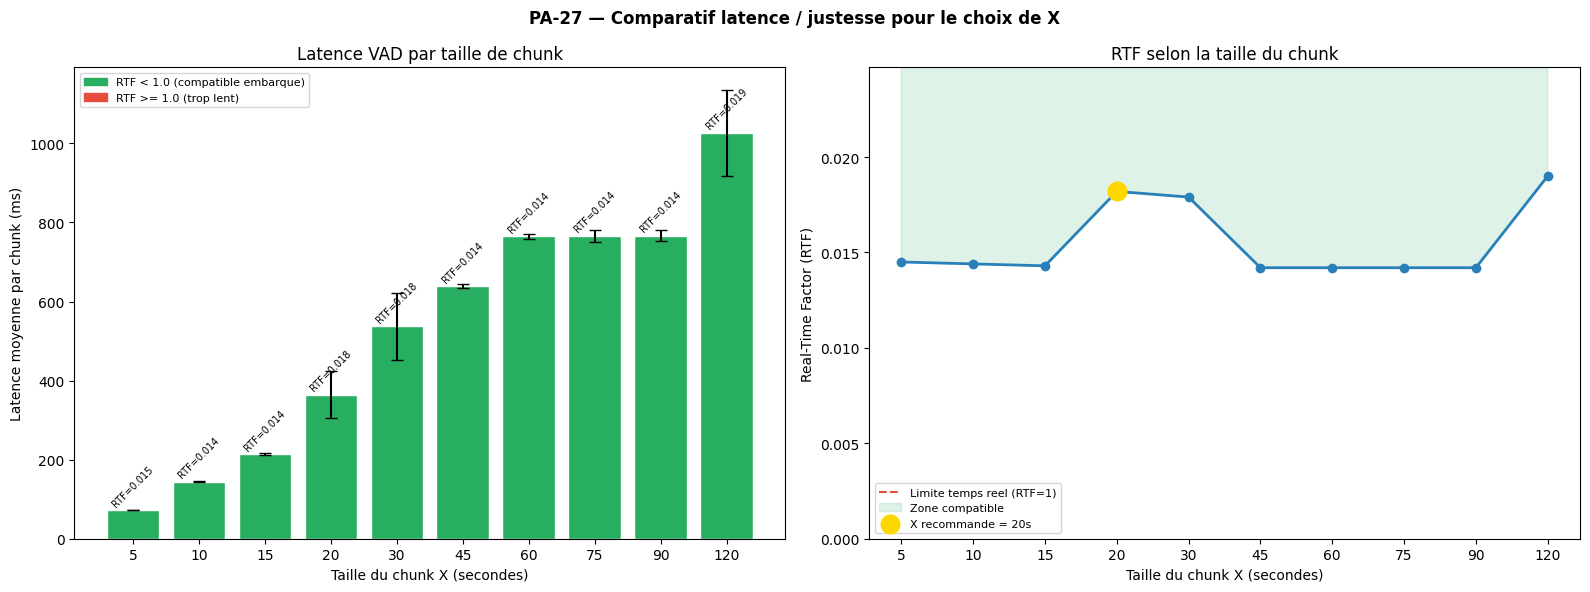

Graphique sauvegarde -> ami_converted/Audio_test (1)_pa27_benchmark.png


In [10]:
import time, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if not converted_files:
    raise RuntimeError('Aucun fichier converti. Executer la cellule Upload d abord.')

audio_path_bench = converted_files[0]
waveform_b, _   = torchaudio.load(audio_path_bench)
audio_1d_bench  = waveform_b.squeeze(0)
audio_duration_bench = audio_1d_bench.shape[0] / SAMPLE_RATE

print('=' * 65)
print('  PA-27 — BENCHMARK CHUNKS GLISSANTS (10 tailles testees)')
print('=' * 65)
print(f'  Fichier      : {audio_path_bench}')
print(f'  Duree audio  : {audio_duration_bench:.2f} s')
print()

# 10 tailles de chunks : de 5s a 120s
CHUNK_SIZES = [5, 10, 15, 20, 30, 45, 60, 75, 90, 120]
N_RUNS      = 3  # passages par taille pour une moyenne stable

bench_results = []

for chunk_s in CHUNK_SIZES:
    # Si le chunk depasse la duree du fichier, on prend la duree entiere
    effective_chunk_s = min(chunk_s, audio_duration_bench)
    chunk_samples = int(effective_chunk_s * SAMPLE_RATE)
    n_chunks = max(1, int(audio_1d_bench.shape[0] / chunk_samples))
    latencies_runs = []

    for run in range(N_RUNS):
        t_start = time.perf_counter()
        for i in range(n_chunks):
            chunk = audio_1d_bench[i * chunk_samples : (i + 1) * chunk_samples]
            if chunk.shape[0] < 1600:
                continue
            _ = get_speech_timestamps(
                chunk, vad_model,
                sampling_rate=SAMPLE_RATE,
                threshold=0.5,
                min_speech_duration_ms=300,
                min_silence_duration_ms=200
            )
        t_end = time.perf_counter()
        latencies_runs.append((t_end - t_start) / n_chunks)

    lat_mean = float(np.mean(latencies_runs))
    lat_std  = float(np.std(latencies_runs))
    rtf      = lat_mean / effective_chunk_s

    # Appreciation qualitative du contexte pour la diarisation
    if chunk_s < 8:
        quality  = 'Mediocre (contexte trop court)'
        q_score  = 1
    elif chunk_s <= 15:
        quality  = 'Bonne (equilibre latence / contexte)'
        q_score  = 3
    elif chunk_s <= 30:
        quality  = 'Tres bonne (contexte riche)'
        q_score  = 4
    elif chunk_s <= 60:
        quality  = 'Excellente (contexte maximal)'
        q_score  = 3
    else:
        quality  = 'Excellente mais latence elevee'
        q_score  = 2

    compatible = 'Oui' if rtf < 1.0 else 'Non (RTF >= 1)'

    bench_results.append({
        'chunk_s':    chunk_s,
        'effective_s': effective_chunk_s,
        'n_chunks':   n_chunks,
        'lat_mean_ms': round(lat_mean * 1000, 1),
        'lat_std_ms':  round(lat_std  * 1000, 1),
        'rtf':         round(rtf, 4),
        'compatible':  compatible,
        'quality':     quality,
        'q_score':     q_score,
    })

# ── Tableau texte ─────────────────────────────────────────────────────
print(f"{'X (s)':>6} | {'Eff. (s)':>8} | {'Nb chunks':>9} | {'Lat. moy (ms)':>14} | {'+-std':>7} | {'RTF':>7} | {'Embarque':>10} | Qualite diarisation")
print('-' * 105)

best_idx, best_score = None, -1
for i, r in enumerate(bench_results):
    if r['rtf'] < 1.0 and r['q_score'] > best_score:
        best_score, best_idx = r['q_score'], i

for i, r in enumerate(bench_results):
    tag = '  <-- RECOMMANDE' if i == best_idx else ''
    print(f"{r['chunk_s']:>6} | {r['effective_s']:>8.1f} | {r['n_chunks']:>9} | "
          f"{r['lat_mean_ms']:>14.1f} | {r['lat_std_ms']:>7.1f} | "
          f"{r['rtf']:>7.4f} | {r['compatible']:>10} | {r['quality']}{tag}")

print('-' * 105)

X_opt = bench_results[best_idx]['chunk_s'] if best_idx is not None else 30
best_r = bench_results[best_idx] if best_idx is not None else bench_results[4]
print(f'\n  Valeur X recommandee : {X_opt} secondes')
print(f'  RTF correspondant   : {best_r["rtf"]:.4f}')
print(f'  Qualite diarisation : {best_r["quality"]}')
print(f'  Resultat partiel    : toutes les {X_opt}s sans attendre la fin de la conversation')
print('=' * 65)

# ── Graphiques ────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

xs        = [str(r['chunk_s']) for r in bench_results]
lats      = [r['lat_mean_ms'] for r in bench_results]
stds      = [r['lat_std_ms']  for r in bench_results]
rtfs      = [r['rtf']         for r in bench_results]
bar_cols  = ['#e74c3c' if r['rtf'] >= 1.0 else '#27ae60' for r in bench_results]

bars = ax1.bar(xs, lats, color=bar_cols, edgecolor='white', yerr=stds, capsize=4)
ax1.set_xlabel('Taille du chunk X (secondes)')
ax1.set_ylabel('Latence moyenne par chunk (ms)')
ax1.set_title('Latence VAD par taille de chunk')
for bar, r in zip(bars, bench_results):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(stds) * 0.05,
             f'RTF={r["rtf"]:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)
ax1.legend(handles=[
    mpatches.Patch(color='#27ae60', label='RTF < 1.0 (compatible embarque)'),
    mpatches.Patch(color='#e74c3c', label='RTF >= 1.0 (trop lent)')
], fontsize=8)

ax2.plot(xs, rtfs, marker='o', color='#2980b9', linewidth=2)
ax2.axhline(y=1.0, color='#e74c3c', linestyle='--', linewidth=1.5, label='Limite temps reel (RTF=1)')
ax2.fill_between(xs, rtfs, 1.0,
                 where=[r < 1.0 for r in rtfs], alpha=0.15, color='#27ae60', label='Zone compatible')
if best_idx is not None:
    ax2.scatter([xs[best_idx]], [rtfs[best_idx]], color='gold', s=180, zorder=5,
                label=f'X recommande = {X_opt}s')
ax2.set_xlabel('Taille du chunk X (secondes)')
ax2.set_ylabel('Real-Time Factor (RTF)')
ax2.set_title('RTF selon la taille du chunk')
ax2.legend(fontsize=8)
ax2.set_ylim(0, max(rtfs) * 1.3)

plt.suptitle('PA-27 — Comparatif latence / justesse pour le choix de X', fontweight='bold')
plt.tight_layout()
bench_img = audio_path_bench.replace('.wav', '_pa27_benchmark.png')
plt.savefig(bench_img, dpi=150)
plt.show()
print(f'Graphique sauvegarde -> {bench_img}')


## 5quater. Pipeline par chunks glissants (X déterminé par PA-27)

Exécution du pipeline complet (VAD + Diarisation) en mode chunks glissants avec la valeur de X choisie ci-dessus. Un résultat JSON partiel est émis après chaque chunk.

> **Note :** cette cellule dépend de `X_opt` calculé en 5ter. Exécuter 5ter avant de lancer celle-ci.


In [11]:
# extract_annotation() est definie en cellule 4 (pipeline principal)
chunk_samples  = int(X_opt * SAMPLE_RATE)
chunks_results = {}

for audio_path in converted_files:
    print('\n' + '=' * 60)
    print(f'  Chunks glissants ({X_opt}s) : {audio_path}')
    print('=' * 60)

    waveform, sr = torchaudio.load(audio_path)
    audio_1d = waveform.squeeze(0)
    duration  = audio_1d.shape[0] / SAMPLE_RATE
    n_chunks  = max(1, int(duration / X_opt))
    all_segs  = []

    for i in range(n_chunks):
        t_start = i * X_opt
        t_end   = min((i + 1) * X_opt, duration)
        chunk   = audio_1d[i * chunk_samples : (i + 1) * chunk_samples]
        if chunk.shape[0] < SAMPLE_RATE:
            continue

        # VAD sur le chunk
        speech_ts = get_speech_timestamps(
            chunk, vad_model,
            sampling_rate=SAMPLE_RATE,
            threshold=0.5,
            min_speech_duration_ms=300,
            min_silence_duration_ms=200
        )

        # Diarisation sur le chunk via fichier temporaire
        chunk_path = f'ami_converted/_chunk_{i:04d}.wav'
        torchaudio.save(chunk_path, chunk.unsqueeze(0), SAMPLE_RATE)
        try:
            diar_output = pipeline(chunk_path)
            annotation  = extract_annotation(diar_output)   # normalisation robuste
            for segment, track, speaker in annotation.itertracks(yield_label=True):
                all_segs.append({
                    'start':   round(segment.start + t_start, 3),
                    'end':     round(segment.end   + t_start, 3),
                    'speaker': speaker,
                    'chunk':   i
                })
        except Exception as e:
            print(f'  ERREUR chunk {i} : {e}')
        finally:
            if os.path.exists(chunk_path):
                os.remove(chunk_path)

        spk_so_far = list(set(s['speaker'] for s in all_segs))
        print(f'  [Chunk {i+1:2d}/{n_chunks}] {t_start:.0f}s -> {t_end:.0f}s | '
              f'VAD: {len(speech_ts)} seg | Locuteurs: {spk_so_far}')

    speakers_detected = list(set(s['speaker'] for s in all_segs))
    result_chunks = {
        'metadata': {
            'audio_file':            os.path.basename(audio_path),
            'duration_s':            round(duration, 3),
            'processed_at':          datetime.datetime.now().isoformat(),
            'vad_model':             'silero-vad',
            'diarization_model':     'pyannote/speaker-diarization-3.1',
            'chunk_size_s':          X_opt,
            'n_chunks':              n_chunks,
            'num_speakers_detected': len(speakers_detected)
        },
        'speakers': speakers_detected,
        'segments': all_segs
    }
    chunks_results[audio_path] = result_chunks

    json_path = audio_path.replace('.wav', '_chunks_output.json')
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(result_chunks, f, ensure_ascii=False, indent=2)
    print(f'\n  JSON sauvegarde -> {json_path}')
    print(f'  Locuteurs : {len(speakers_detected)} | Segments : {len(all_segs)}')

print(f'\nPipeline chunks termine sur {len(converted_files)} fichier(s)')



  Chunks glissants (20s) : ami_converted/Audio_test (1).wav
  [Chunk  1/2] 0s -> 20s | VAD: 4 seg | Locuteurs: ['SPEAKER_01', 'SPEAKER_00', 'SPEAKER_03', 'SPEAKER_02']
  [Chunk  2/2] 20s -> 40s | VAD: 5 seg | Locuteurs: ['SPEAKER_01', 'SPEAKER_00', 'SPEAKER_03', 'SPEAKER_02']

  JSON sauvegarde -> ami_converted/Audio_test (1)_chunks_output.json
  Locuteurs : 4 | Segments : 21

Pipeline chunks termine sur 1 fichier(s)


## 6. Récapitulatif
Synthèse des résultats sur l'ensemble de l'échantillon.

In [12]:
print('=' * 60)
print('  RECAPITULATIF — PA-30')
print('=' * 60)
for audio_path, result in all_results.items():
    m = result['metadata']
    print(f"\n  {m['audio_file']}")
    print(f"     Duree         : {m['duration_s']}s")
    print(f"     Locuteurs     : {m['num_speakers_detected']}")
    print(f"     Segments      : {len(result['segments'])}")
    print(f"     Traite le     : {m['processed_at']}")
print('\n' + '=' * 60)
print(f'  {len(all_results)} fichier(s) traite(s) avec succes')
print('  JSON et timelines sauvegardes dans ami_converted/')
print('=' * 60)

  RECAPITULATIF — PA-30

  Audio_test (1).wav
     Duree         : 53.931s
     Locuteurs     : 4
     Segments      : 33
     Traite le     : 2026-06-16T07:55:49.788906

  1 fichier(s) traite(s) avec succes
  JSON et timelines sauvegardes dans ami_converted/


## 7. Reconnaissance d'émotions (SER) — PA-09 optionnel
**Modèle : `ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition` (HuggingFace)**

Basé sur le survey (*George & Ilyas, Neurocomputing 2024*), les modèles pré-entraînés de type
wav2vec2 / HuBERT sont l'état de l'art pour la SER robuste au bruit — parfaitement adapté à
l'habitacle automobile (bruit moteur, route, passagers).

**Architecture retenue :**
- Le modèle est appliqué **segment par segment** sur les sorties de la diarisation
- Chaque segment reçoit un label émotionnel parmi : `angry`, `disgust`, `fearful`, `happy`, `neutral`, `sad`, `surprised`
- Les résultats sont enrichis dans `all_results` et exportés dans le JSON Stellantis final

> **Note :** Cette cellule est optionnelle (step 9 du pipeline cible). Si le modèle est trop lent
> sur CPU Colab, réduire `MAX_SEG_DURATION` ou activer le GPU dans *Runtime > Changer le type de runtime*.


In [13]:
# Installation du modèle SER HuggingFace
# (separee de l'install principale pour ne pas recharger pyannote)
!pip install -q transformers datasets accelerate
print('Transformers installe')


Transformers installe


In [14]:
import torch, torchaudio, os, numpy as np
from transformers import pipeline as hf_pipeline

# ── 1. Chargement du modele SER ──────────────────────────────────────────────
print('Chargement du modele SER (wav2vec2)...')

DEVICE = 0 if torch.cuda.is_available() else -1
device_label = 'GPU' if DEVICE == 0 else 'CPU'
print(f'  Device : {device_label}')

ser_pipeline = hf_pipeline(
    task='audio-classification',
    model='ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition',
    device=DEVICE
)

EMOTIONS_FR = {
    'angry':     'colere',
    'disgust':   'degout',
    'fearful':   'peur',
    'happy':     'joie',
    'neutral':   'neutre',
    'sad':       'tristesse',
    'surprised': 'surprise',
}

print(f'  Modele charge : ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition')
print(f'  Classes : {list(EMOTIONS_FR.keys())}')

# ── 2. Parametres ─────────────────────────────────────────────────────────────
SAMPLE_RATE       = 16000
MAX_SEG_DURATION  = 10.0   # secondes max par segment (tronque si trop long)
MIN_SEG_DURATION  = 0.5    # ignore les segments trop courts

# ── 3. Inference segment par segment ──────────────────────────────────────────
print()
print('=' * 60)
print('  SER — ANALYSE EMOTIONNELLE PAR SEGMENT')
print('=' * 60)

for audio_path, result in all_results.items():
    print(f'\n  Fichier : {audio_path}')

    waveform, sr = torchaudio.load(audio_path)
    audio_1d = waveform.squeeze(0).numpy()
    total_dur = len(audio_1d) / SAMPLE_RATE

    segments_with_emotion = []
    emotion_counts = {}

    for seg in result['segments']:
        start_s = seg['start']
        end_s   = min(seg['end'], total_dur)
        dur     = end_s - start_s

        if dur < MIN_SEG_DURATION:
            seg['emotion'] = 'neutre'
            seg['emotion_score'] = 1.0
            seg['emotion_en'] = 'neutral'
            segments_with_emotion.append(seg)
            continue

        # Extraction de l'audio du segment (tronque a MAX_SEG_DURATION)
        start_idx = int(start_s * SAMPLE_RATE)
        end_idx   = int(min(end_s, start_s + MAX_SEG_DURATION) * SAMPLE_RATE)
        seg_audio = audio_1d[start_idx:end_idx]

        try:
            preds = ser_pipeline(
                {'array': seg_audio, 'sampling_rate': SAMPLE_RATE},
                top_k=1
            )
            top   = preds[0]
            label = top['label'].lower()
            score = round(top['score'], 3)
        except Exception as e:
            label, score = 'neutral', 0.0
            print(f'    ERREUR seg [{start_s:.1f}-{end_s:.1f}s] : {e}')

        emotion_fr = EMOTIONS_FR.get(label, label)
        seg['emotion']       = emotion_fr
        seg['emotion_score'] = score
        seg['emotion_en']    = label
        segments_with_emotion.append(seg)

        emotion_counts[emotion_fr] = emotion_counts.get(emotion_fr, 0) + 1

        print(f'    [{start_s:6.2f}s -> {end_s:6.2f}s] {seg["speaker"]:12s} | '
              f'{emotion_fr:12s} ({score:.2f})')

    # Mise a jour des segments dans all_results
    result['segments'] = segments_with_emotion

    # Emotion dominante sur le fichier
    dominant = max(emotion_counts, key=emotion_counts.get) if emotion_counts else 'neutre'
    result['metadata']['dominant_emotion'] = dominant
    result['metadata']['emotion_counts']   = emotion_counts

    print(f'\n  Emotion dominante : {dominant}')
    print(f'  Distribution      : {emotion_counts}')

print('\nSER termine sur tous les fichiers')


Chargement du modele SER (wav2vec2)...
  Device : CPU


config.json:   0%|          | 0.00/2.28k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition
Key                      | Status     | 
-------------------------+------------+-
classifier.dense.weight  | UNEXPECTED | 
classifier.output.bias   | UNEXPECTED | 
classifier.output.weight | UNEXPECTED | 
classifier.dense.bias    | UNEXPECTED | 
projector.bias           | MISSING    | 
classifier.weight        | MISSING    | 
classifier.bias          | MISSING    | 
projector.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

  Modele charge : ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition
  Classes : ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

  SER — ANALYSE EMOTIONNELLE PAR SEGMENT

  Fichier : ami_converted/Audio_test (1).wav
    [  1.57s ->   2.09s] SPEAKER_00   | joie         (0.13)
    [  4.74s ->   5.94s] SPEAKER_03   | tristesse    (0.13)
    [  5.94s ->   6.78s] SPEAKER_00   | tristesse    (0.14)
    [  7.19s ->  11.71s] SPEAKER_00   | tristesse    (0.13)
    [ 12.06s ->  13.85s] SPEAKER_02   | tristesse    (0.14)
    [ 14.15s ->  16.03s] SPEAKER_03   | tristesse    (0.13)
    [ 16.03s ->  16.59s] SPEAKER_00   | joie         (0.13)
    [ 16.77s ->  20.05s] SPEAKER_00   | degout       (0.13)
    [ 20.26s ->  23.35s] SPEAKER_00   | tristesse    (0.13)
    [ 23.55s ->  25.41s] SPEAKER_02   | tristesse    (0.13)
    [ 26.04s ->  27.34s] SPEAKER_00   | tristesse    (0.13)
    [ 27.69s ->  28.90s] SPEAKER_00   | degout       (0.13)
    [ 29.21s ->  32.04s] SPEAKER

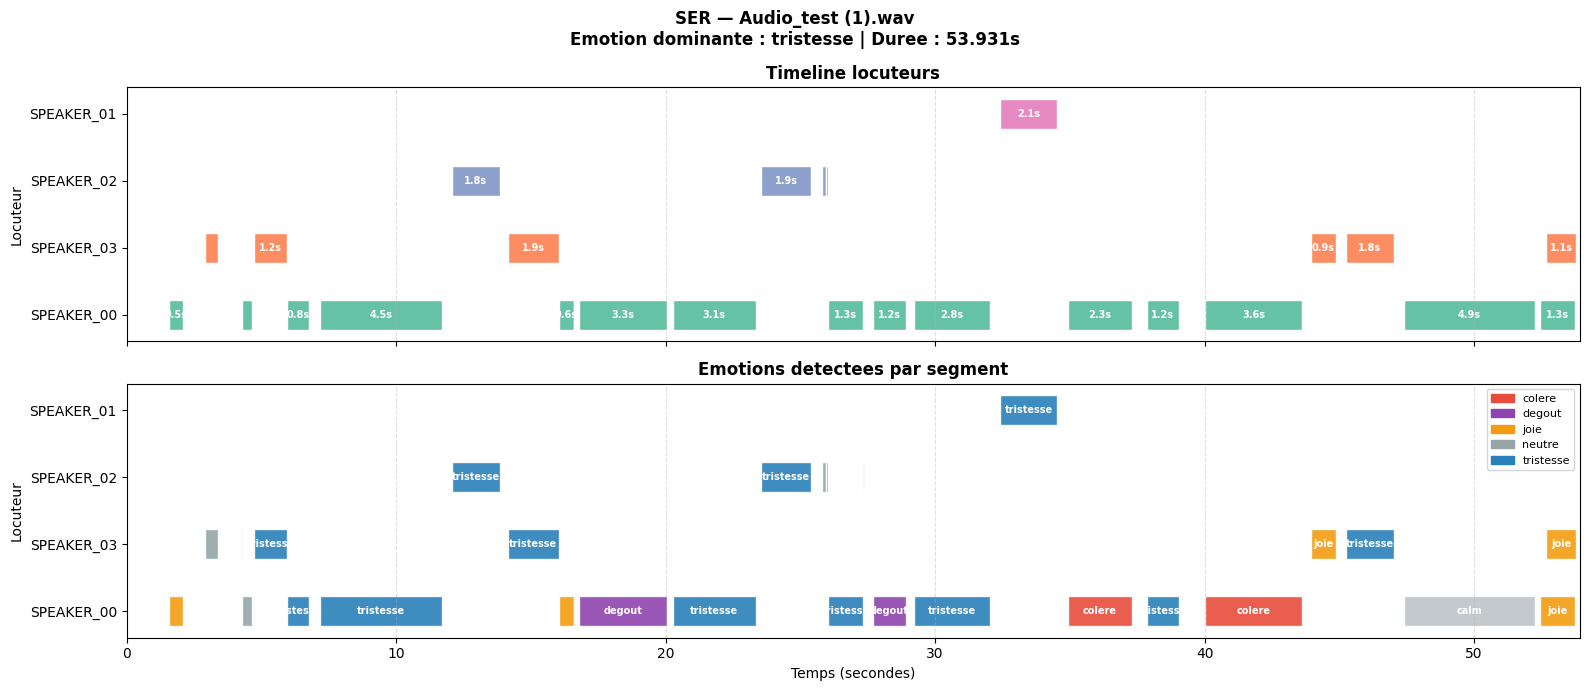

Timeline SER sauvegardee -> ami_converted/Audio_test (1)_ser_timeline.png


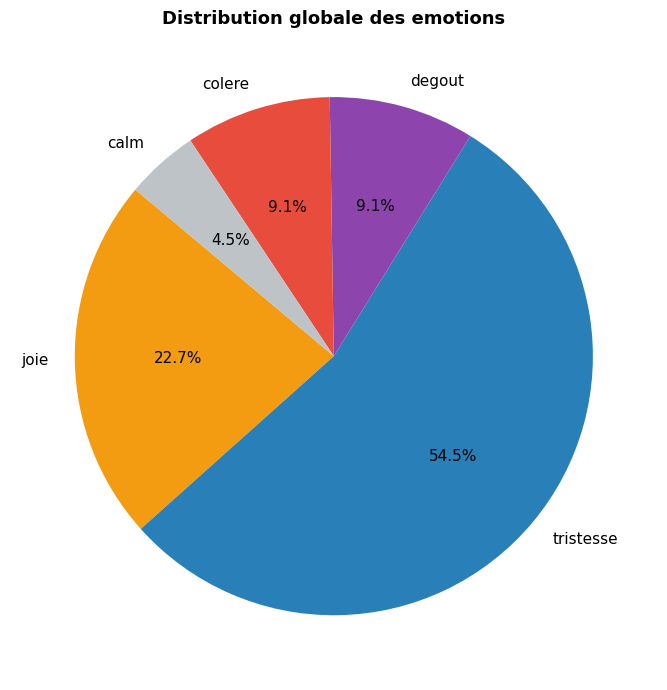

Camembert sauvegarde -> ami_converted/ser_global_pie.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Palette couleurs par emotion
EMOTION_COLORS = {
    'colere':     '#e74c3c',
    'degout':     '#8e44ad',
    'peur':       '#2c3e50',
    'joie':       '#f39c12',
    'neutre':     '#95a5a6',
    'tristesse':  '#2980b9',
    'surprise':   '#27ae60',
}
DEFAULT_COLOR = '#bdc3c7'

def merge_segments_full(segs, gap=0.3):
    merged = []
    for seg in sorted(segs, key=lambda x: x['start']):
        if (merged
                and seg['speaker'] == merged[-1]['speaker']
                and seg.get('emotion') == merged[-1].get('emotion')
                and seg['start'] - merged[-1]['end'] < gap):
            merged[-1]['end'] = seg['end']
        else:
            merged.append(dict(seg))
    return merged

for audio_path, result in all_results.items():
    segments = result['segments']
    if not any('emotion' in s for s in segments):
        print(f'  Pas de donnees SER pour {audio_path} - exclure')
        continue

    segments_m = merge_segments_full(segments)
    speakers   = list(dict.fromkeys(s['speaker'] for s in segments_m))
    emotions   = list(dict.fromkeys(s.get('emotion', 'neutre') for s in segments_m))

    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

    # ── Row 1 : timeline par locuteur (couleur = locuteur) ───────────────────
    spk_colors = plt.cm.Set2.colors
    spk_cmap   = {spk: spk_colors[i % len(spk_colors)] for i, spk in enumerate(speakers)}

    for seg in segments_m:
        w = seg['end'] - seg['start']
        axes[0].barh(y=seg['speaker'], width=w, left=seg['start'],
                     color=spk_cmap[seg['speaker']], edgecolor='white', height=0.45)
        if w > 0.5:
            axes[0].text(seg['start'] + w/2, seg['speaker'],
                         f'{w:.1f}s', ha='center', va='center',
                         fontsize=7, color='white', fontweight='bold')

    axes[0].set_title('Timeline locuteurs', fontweight='bold')
    axes[0].set_ylabel('Locuteur')
    axes[0].grid(axis='x', linestyle='--', alpha=0.4)

    # ── Row 2 : timeline par emotion (couleur = emotion) ─────────────────────
    for seg in segments_m:
        emo = seg.get('emotion', 'neutre')
        w   = seg['end'] - seg['start']
        col = EMOTION_COLORS.get(emo, DEFAULT_COLOR)
        axes[1].barh(y=seg['speaker'], width=w, left=seg['start'],
                     color=col, edgecolor='white', height=0.45, alpha=0.9)
        if w > 0.8:
            axes[1].text(seg['start'] + w/2, seg['speaker'],
                         emo, ha='center', va='center',
                         fontsize=7, color='white', fontweight='bold')

    axes[1].set_title('Emotions detectees par segment', fontweight='bold')
    axes[1].set_xlabel('Temps (secondes)')
    axes[1].set_ylabel('Locuteur')
    axes[1].grid(axis='x', linestyle='--', alpha=0.4)

    # Legende emotions
    patches = [mpatches.Patch(color=EMOTION_COLORS.get(e, DEFAULT_COLOR), label=e)
               for e in EMOTION_COLORS if e in emotions]
    axes[1].legend(handles=patches, loc='upper right', fontsize=8)

    dur = result['metadata']['duration_s']
    dom = result['metadata'].get('dominant_emotion', '?')
    axes[0].set_xlim(0, dur)
    fig.suptitle(
        f"SER — {result['metadata']['audio_file']}\n"
        f"Emotion dominante : {dom} | Duree : {dur}s",
        fontweight='bold', fontsize=12
    )
    plt.tight_layout()

    img_path = audio_path.replace('.wav', '_ser_timeline.png')
    plt.savefig(img_path, dpi=150)
    plt.show()
    print(f'Timeline SER sauvegardee -> {img_path}')

# ── Camembert emotions globales (tous fichiers) ───────────────────────────────
global_counts = {}
for result in all_results.values():
    for emo, cnt in result['metadata'].get('emotion_counts', {}).items():
        global_counts[emo] = global_counts.get(emo, 0) + cnt

if global_counts:
    fig, ax = plt.subplots(figsize=(7, 7))
    labels  = list(global_counts.keys())
    sizes   = list(global_counts.values())
    colors  = [EMOTION_COLORS.get(l, DEFAULT_COLOR) for l in labels]
    ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
           startangle=140, textprops={'fontsize': 11})
    ax.set_title('Distribution globale des emotions', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('ami_converted/ser_global_pie.png', dpi=150)
    plt.show()
    print('Camembert sauvegarde -> ami_converted/ser_global_pie.png')


## 8. Production de la sortie JSON structurée Stellantis
**Story PA-?? | Complexité : 5**

En tant que système, je veux produire une sortie JSON structurée afin que Stellantis puisse exploiter les données dans ses systèmes embarqués.

Le format retenu est conçu pour être :
- **Intégrable** dans un système embarqué Raspberry Pi (sortie fichier locale + passerelle HTTP optionnelle)
- **Exploitable** directement par les équipes Stellantis (structure fixe, champs documentés)
- **Validé** via un schéma JSON minimal avant export

**Critère d'acceptation :** JSON généré correctement, schema valide, passerelle HTTP testée.


In [16]:
import json, datetime, os, uuid
import urllib.request, urllib.error

# ── 1. Schéma de validation minimal ─────────────────────────────────
REQUIRED_METADATA_KEYS = {
    'audio_file', 'duration_s', 'processed_at',
    'vad_model', 'diarization_model', 'num_speakers_detected'
}
REQUIRED_SEGMENT_KEYS = {'start', 'end', 'speaker'}

def validate_json_output(data: dict) -> list:
    """Retourne une liste d'erreurs (vide = valide)."""
    errors = []
    meta = data.get('metadata', {})
    missing_meta = REQUIRED_METADATA_KEYS - set(meta.keys())
    if missing_meta:
        errors.append(f'metadata manquants : {missing_meta}')
    if 'speakers' not in data or not isinstance(data['speakers'], list):
        errors.append('champ speakers absent ou invalide')
    if 'segments' not in data or not isinstance(data['segments'], list):
        errors.append('champ segments absent ou invalide')
    for idx, seg in enumerate(data.get('segments', [])):
        missing_seg = REQUIRED_SEGMENT_KEYS - set(seg.keys())
        if missing_seg:
            errors.append(f'segment[{idx}] champs manquants : {missing_seg}')
        if seg.get('end', 0) <= seg.get('start', 0):
            errors.append(f'segment[{idx}] timestamps invalides (end <= start)')
    return errors


# ── 2. Format JSON Stellantis enrichi ────────────────────────────────
def build_stellantis_json(result: dict, source: str = 'pipeline') -> dict:
    """
    Construit le JSON final au format Stellantis a partir du resultat brut du pipeline.
    source : 'pipeline' (traitement complet) | 'chunks' (mode chunks glissants)
    """
    meta = result['metadata']
    segments = result.get('segments', [])

    # Calcul du temps de parole par locuteur
    speech_time = {}
    for seg in segments:
        spk = seg['speaker']
        speech_time[spk] = round(speech_time.get(spk, 0) + (seg['end'] - seg['start']), 3)

    stellantis_output = {
        'schema_version': '1.0',
        'pipeline_id':    str(uuid.uuid4()),
        'generated_at':   datetime.datetime.now().isoformat(),
        'source_mode':    source,
        'metadata': {
            'audio_file':             meta['audio_file'],
            'duration_s':             meta['duration_s'],
            'processed_at':           meta['processed_at'],
            'vad_model':              meta['vad_model'],
            'diarization_model':      meta['diarization_model'],
            'num_speakers_detected':  meta['num_speakers_detected'],
            'chunk_size_s':           meta.get('chunk_size_s', None),
            'n_chunks':               meta.get('n_chunks', None),
        },
        'speakers': [
            {
                'id':          spk,
                'total_speech_s': speech_time.get(spk, 0),
                'role':        'unknown'   # a enrichir : 'driver' | 'passenger' | 'ai'
            }
            for spk in result.get('speakers', [])
        ],
        'segments': [
            {
                'id':       idx,
                'start':    seg['start'],
                'end':      seg['end'],
                'duration': round(seg['end'] - seg['start'], 3),
                'speaker':  seg['speaker'],
                'chunk':    seg.get('chunk', None)
            }
            for idx, seg in enumerate(segments)
        ],
        'summary': {
            'total_speech_s':   round(sum(speech_time.values()), 3),
            'silence_s':        round(meta['duration_s'] - sum(speech_time.values()), 3),
            'num_segments':     len(segments),
            'speakers_summary': speech_time
        }
    }
    return stellantis_output


# ── 3. Export + validation pour chaque fichier ───────────────────────
GATEWAY_URL = None   # ex: 'http://192.168.1.10:5000/api/diarization'
# Mettre l'URL de la passerelle Stellantis ici pour activer l'envoi HTTP.
# Laisser None pour desactiver (mode fichier seul).

all_stellantis = {}

sources = [
    (all_results,   'pipeline'),
    (chunks_results if 'chunks_results' in dir() and chunks_results else {}, 'chunks'),
]

for results_dict, source_label in sources:
    for audio_path, result in results_dict.items():
        print(f'\n{"="*60}')
        print(f'  Export JSON Stellantis [{source_label}] : {os.path.basename(audio_path)}')
        print('='*60)

        stellantis = build_stellantis_json(result, source=source_label)

        # Validation schema
        errors = validate_json_output(stellantis)
        if errors:
            print(f'  VALIDATION ECHOUEE :')
            for e in errors:
                print(f'    - {e}')
        else:
            print(f'  Validation schema : OK')

        # Affichage resume
        s = stellantis['summary']
        print(f'  Locuteurs       : {stellantis["metadata"]["num_speakers_detected"]}')
        print(f'  Segments        : {s["num_segments"]}')
        print(f'  Temps de parole : {s["total_speech_s"]}s / {stellantis["metadata"]["duration_s"]}s')
        print(f'  Silence total   : {s["silence_s"]}s')
        for spk, t in s['speakers_summary'].items():
            pct = round(100 * t / stellantis['metadata']['duration_s'], 1) if stellantis['metadata']['duration_s'] > 0 else 0
            print(f'    {spk} : {t}s ({pct}%)')

        # Export fichier local
        suffix  = f'_stellantis_{source_label}.json'
        out_path = audio_path.replace('.wav', suffix)
        with open(out_path, 'w', encoding='utf-8') as f:
            json.dump(stellantis, f, ensure_ascii=False, indent=2)
        print(f'  Fichier local   : {out_path}')

        # Passerelle HTTP (optionnelle)
        if GATEWAY_URL:
            try:
                payload = json.dumps(stellantis).encode('utf-8')
                req = urllib.request.Request(
                    GATEWAY_URL,
                    data=payload,
                    headers={'Content-Type': 'application/json'},
                    method='POST'
                )
                with urllib.request.urlopen(req, timeout=5) as resp:
                    status = resp.getcode()
                    print(f'  Passerelle HTTP : HTTP {status} -> OK')
            except urllib.error.URLError as e:
                print(f'  Passerelle HTTP : ERREUR ({e.reason}) — export local conserve')
        else:
            print(f'  Passerelle HTTP : desactivee (GATEWAY_URL = None)')

        all_stellantis[audio_path + '_' + source_label] = stellantis

print(f'\n{len(all_stellantis)} fichier(s) exporte(s) au format Stellantis')

# Apercu du JSON final (premier fichier)
if all_stellantis:
    first = next(iter(all_stellantis.values()))
    print('\n--- Apercu JSON Stellantis (premier fichier) ---')
    preview = dict(first)
    preview['segments'] = preview['segments'][:3]  # 3 premiers segments seulement
    print(json.dumps(preview, ensure_ascii=False, indent=2))



  Export JSON Stellantis [pipeline] : Audio_test (1).wav
  Validation schema : OK
  Locuteurs       : 4
  Segments        : 33
  Temps de parole : 45.376s / 53.931s
  Silence total   : 8.555s
    SPEAKER_00 : 31.961s (59.3%)
    SPEAKER_03 : 7.408s (13.7%)
    SPEAKER_02 : 3.881s (7.2%)
    SPEAKER_01 : 2.126s (3.9%)
  Fichier local   : ami_converted/Audio_test (1)_stellantis_pipeline.json
  Passerelle HTTP : desactivee (GATEWAY_URL = None)

  Export JSON Stellantis [chunks] : Audio_test (1).wav
  Validation schema : OK
  Locuteurs       : 4
  Segments        : 21
  Temps de parole : 31.808s / 53.931s
  Silence total   : 22.123s
    SPEAKER_00 : 21.92s (40.6%)
    SPEAKER_02 : 3.813s (7.1%)
    SPEAKER_03 : 1.772s (3.3%)
    SPEAKER_01 : 4.303s (8.0%)
  Fichier local   : ami_converted/Audio_test (1)_stellantis_chunks.json
  Passerelle HTTP : desactivee (GATEWAY_URL = None)

2 fichier(s) exporte(s) au format Stellantis

--- Apercu JSON Stellantis (premier fichier) ---
{
  "schema_versi

In [17]:
# Mise a jour du JSON Stellantis pour inclure les emotions
# (a executer APRES la cellule JSON Stellantis si SER a ete fait)

import json, os

for audio_path, stellantis in all_stellantis.items():
    # Trouver le bon result dans all_results
    audio_key = audio_path.rsplit('_pipeline', 1)[0].rsplit('_chunks', 1)[0]
    source    = 'pipeline' if '_pipeline' in audio_path else 'chunks'

    result = all_results.get(audio_key) or all_results.get(
        next((k for k in all_results if audio_key in k), None), None
    )
    if not result:
        continue

    # Enrichir les segments Stellantis avec l'emotion
    seg_map = {(s['start'], s['end']): s for s in result.get('segments', [])}
    for seg in stellantis.get('segments', []):
        key = (seg['start'], seg['end'])
        src = seg_map.get(key, {})
        seg['emotion']       = src.get('emotion', 'neutre')
        seg['emotion_score'] = src.get('emotion_score', None)

    # Enrichir les speakers avec emotion dominante
    for spk_obj in stellantis.get('speakers', []):
        spk = spk_obj['id']
        spk_emotions = [
            s.get('emotion', 'neutre')
            for s in result.get('segments', [])
            if s.get('speaker') == spk and 'emotion' in s
        ]
        if spk_emotions:
            dominant = max(set(spk_emotions), key=spk_emotions.count)
            spk_obj['dominant_emotion'] = dominant

    # Ajouter dominant global au metadata
    stellantis['metadata']['dominant_emotion'] = result['metadata'].get('dominant_emotion', 'neutre')
    stellantis['metadata']['emotion_counts']   = result['metadata'].get('emotion_counts', {})

    # Re-sauvegarder le JSON enrichi
    suffix   = f'_stellantis_{source}.json'
    out_path = audio_key.replace('.wav', suffix)
    if os.path.exists(out_path):
        with open(out_path, 'w', encoding='utf-8') as f:
            json.dump(stellantis, f, ensure_ascii=False, indent=2)
        print(f'JSON Stellantis enrichi (emotions) -> {out_path}')

print('Patch JSON emotions termine')


JSON Stellantis enrichi (emotions) -> ami_converted/Audio_test (1)_stellantis_pipeline.json
JSON Stellantis enrichi (emotions) -> ami_converted/Audio_test (1)_stellantis_chunks.json
Patch JSON emotions termine


## Téléchargement des fichiers JSON Stellantis
Télécharge tous les JSON produits (pipeline complet + chunks glissants) directement depuis Colab.

In [18]:
from google.colab import files
import os

print('Telechargement des JSON Stellantis...')
downloaded = 0

# Recupere les chemins depuis all_stellantis (cle = audio_path + '_' + source_label)
for key in all_stellantis:
    # Reconstituer le chemin fichier depuis la cle
    for source_label in ('pipeline', 'chunks'):
        suffix = '_stellantis_' + source_label + '.json'
        if key.endswith('_' + source_label):
            audio_path = key[: -(len('_' + source_label))]
            json_path  = audio_path.replace('.wav', suffix)
            if os.path.exists(json_path):
                print(f'  -> {json_path}')
                files.download(json_path)
                downloaded += 1

# Fallback : chercher tous les JSON Stellantis dans ami_converted/
if downloaded == 0:
    print('Recherche des fichiers JSON dans ami_converted/...')
    for fname in sorted(os.listdir('ami_converted')):
        if 'stellantis' in fname and fname.endswith('.json'):
            path = os.path.join('ami_converted', fname)
            print(f'  -> {path}')
            files.download(path)
            downloaded += 1

print(f'\n{downloaded} fichier(s) telecharge(s)')


Telechargement des JSON Stellantis...
  -> ami_converted/Audio_test (1)_stellantis_pipeline.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  -> ami_converted/Audio_test (1)_stellantis_chunks.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


2 fichier(s) telecharge(s)


## 7. Évaluation des performances — DER (PA-31)
Comparaison des sorties du pipeline aux annotations de référence AMI.
Le DER (Diarization Error Rate) mesure le % de temps mal attribué à un locuteur.
Un DER < 30% est acceptable pour un prototype sur micro unique.

Uploader le zip des annotations AMI (fichiers `.segments.xml`).


In [19]:
from google.colab import files
import zipfile

uploaded_zip = files.upload()
zip_name = list(uploaded_zip.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('ami_annotations/')
print('Annotations extraites')
print(os.listdir('ami_annotations/'))

IndexError: list index out of range

In [20]:
import glob
import xml.etree.ElementTree as ET
import soundfile as sf
from pyannote.core import Segment, Annotation
from pyannote.metrics.diarization import DiarizationErrorRate


def parse_ami_segments(annotations_folder, meeting_id, max_time):
    """Charge les annotations AMI tronquees a max_time (duree audio reelle)."""
    reference = Annotation()
    pattern   = os.path.join(annotations_folder, f'**/{meeting_id}.*.segments.xml')
    files_found = glob.glob(pattern, recursive=True)

    if not files_found:
        print(f'Aucun fichier trouve pour {meeting_id}')
        return None

    total = 0
    for filepath in sorted(files_found):
        speaker = os.path.basename(filepath).split('.')[1]
        tree    = ET.parse(filepath)
        root    = tree.getroot()
        segs    = root.findall('.//segment')
        print(f'  {os.path.basename(filepath)} -> {len(segs)} segments')

        for seg in segs:
            start = float(seg.get('transcriber_start'))
            end   = float(seg.get('transcriber_end'))
            if start >= max_time:
                continue
            end = min(end, max_time)
            if end <= start:
                continue
            reference[Segment(start, end)] = f'SPEAKER_{speaker}'
            total += 1

    print(f'  Reference chargee : {total} segments')
    return reference


def pipeline_to_annotation(segments):
    """Convertit la liste JSON en Annotation pyannote."""
    hypothesis = Annotation()
    for seg in segments:
        hypothesis[Segment(seg['start'], seg['end'])] = seg['speaker']
    return hypothesis


der_metric = DiarizationErrorRate()
print('=' * 60)
print('  CALCUL DU DER — PA-31')
print('=' * 60)

for audio_path, result in all_results.items():
    meeting_id = os.path.basename(audio_path).split('.')[0]
    meeting_id = meeting_id.split(' (')[0].replace('_5min', '')
    print(f'\n  {meeting_id}')

    audio_data, sr_sf = sf.read(audio_path)
    max_time   = len(audio_data) / sr_sf

    reference  = parse_ami_segments('ami_annotations/', meeting_id, max_time)
    if reference is None:
        print('  Reference manquante - fichier ignore')
        continue

    clean_segs = []
    for seg in result['segments']:
        s = max(0, seg['start'])
        e = min(seg['end'], max_time)
        if e > s:
            clean_segs.append({'start': s, 'end': e, 'speaker': seg['speaker']})

    hypothesis = pipeline_to_annotation(clean_segs)
    der        = der_metric(reference, hypothesis)
    print(f'  DER : {der * 100:.1f}%')
    print(f'  Interpretation : {"Acceptable (<30%)" if der < 0.30 else "A optimiser (>30%)"}')

global_der = abs(der_metric)
print(f'\n{"="*60}')
print(f'  DER MOYEN GLOBAL : {global_der * 100:.1f}%')
print(f'  Seuil acceptable : < 30% pour un prototype')
print('='*60)

  CALCUL DU DER — PA-31

  Audio_test
Aucun fichier trouve pour Audio_test
  Reference manquante - fichier ignore

  DER MOYEN GLOBAL : 0.0%
  Seuil acceptable : < 30% pour un prototype


### 7bis. Comparaison visuelle référence vs prédiction
Timeline côte à côte : vérité terrain (annotations AMI) vs sortie du pipeline.


In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import soundfile as sf


def annotation_to_segments(annotation):
    segs = []
    for segment, track, speaker in annotation.itertracks(yield_label=True):
        segs.append({'start': segment.start, 'end': segment.end, 'speaker': speaker})
    return segs


def plot_prediction_vs_reference(reference, hypothesis_segments, title, max_time):
    ref_segments = annotation_to_segments(reference)
    speakers     = sorted(set(
        [s['speaker'] for s in ref_segments] +
        [s['speaker'] for s in hypothesis_segments]
    ))

    colors_map   = plt.cm.Set2.colors
    speaker_colors = {spk: colors_map[i % len(colors_map)] for i, spk in enumerate(speakers)}

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    timelines = [('Verite terrain (AMI)', ref_segments),
                 ('Prediction pipeline', hypothesis_segments)]

    for ax, (name, segs) in zip(axes, timelines):
        for seg in segs:
            ax.barh(y=seg['speaker'], width=seg['end']-seg['start'],
                    left=seg['start'], color=speaker_colors[seg['speaker']],
                    edgecolor='white', height=0.45)
        ax.set_title(name, fontweight='bold')
        ax.set_xlim(0, max_time)
        ax.grid(axis='x', linestyle='--', alpha=0.4)
        ax.set_ylabel('Locuteurs')

    axes[-1].set_xlabel('Temps (secondes)')
    patches = [mpatches.Patch(color=speaker_colors[spk], label=spk) for spk in speakers]
    fig.legend(handles=patches, loc='upper right')
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Tracé pour chaque fichier
for audio_path, result in all_results.items():
    meeting_id = os.path.basename(audio_path).split('.')[0]
    meeting_id = meeting_id.split(' (')[0].replace('_5min', '')

    audio_data, sr_sf = sf.read(audio_path)
    max_time = len(audio_data) / sr_sf

    reference = parse_ami_segments('ami_annotations/', meeting_id, max_time)
    if reference is None:
        continue

    clean_segs = [
        {'start': max(0, seg['start']), 'end': min(seg['end'], max_time), 'speaker': seg['speaker']}
        for seg in result['segments']
        if min(seg['end'], max_time) > max(0, seg['start'])
    ]

    plot_prediction_vs_reference(
        reference, clean_segs,
        title=f'Comparaison diarisation — {meeting_id}',
        max_time=max_time
    )

Aucun fichier trouve pour Audio_test
